# Price-Intent Backtest

Test a long-only trade plan for any Yahoo Finance ticker. Set the ticker, index, intended buy price, wanted sell price, stop loss, sizing, costs, and risk limits in **Block 1**, then run all cells.

The notebook downloads daily OHLCV data, caches it under `cache/price_history/`, checks current index membership using the same cached constituent workflow as `03_index_search.ipynb`, and compares the strategy with buy-and-hold and the selected index.

> This is a daily-bar research backtest, not an execution simulator or financial advice. If both the target and stop are touched during one daily candle, the default assumption is that the stop happened first.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from backtesting import (
    export_backtest_results,
    load_backtest_market_data,
    plot_backtest_results,
    prepare_backtest_results,
    run_price_intent_backtest,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## Block 1: Inputs

Prices are absolute prices in the ticker's trading currency. Use `None` to disable an optional rule. `end_date` is inclusive. Supported index names are `dow30`, `nasdaq100`, `sp500`, `ftse100`, and `ftse250`; a Yahoo benchmark symbol such as `^GSPC` also works, but membership checking is then skipped.

In [2]:
# Instrument and historical window
ticker = "AAPL"
index_name = "sp500"
start_date = "2024-01-01"
end_date = None  # Inclusive; use None for the latest available day

# Trade intent (long-only)
buy_price = 175.00             # Buy-limit intent
sell_price = 210.00            # Profit target; None disables it
stop_loss = 155.00             # Fixed stop; None disables it
trailing_stop_pct = None       # Example: 0.10 for a 10% trailing stop

# Capital, position, and order limits
initial_capital = 100.00
position_size_pct = 1.00       # Fraction of available cash used per entry
max_shares = None              # Example: 50; None means no share cap
whole_shares = False           # False allows fractional shares
max_entries = 1000             # Maximum completed/attempted entries
allow_reentry = True
cooldown_days = 5              # Trading sessions after an exit
min_holding_days = 30          # Minimum trading sessions before a normal exit
max_holding_days = None        # Example: 60; exits at close after this many sessions

# Execution assumptions
commission_per_order = 0.00
slippage_bps = 0.0             # 10 bps = 0.10%
same_day_exit_priority = "stop"  # "stop" (conservative) or "target"
force_exit_at_end = True

# Cache and optional exports
cache_dir = "cache"
cache_max_age_hours = 24
refresh_price_cache = True
check_index_membership = True
export_results = False
save_chart = False

## Block 2: Cached market data

The cache follows the project's existing pattern: local files, configurable expiry, refresh on expiry, and metadata showing whether the cache was used. If a refresh fails but a stale price cache exists, the notebook uses that stale copy and warns.

In [3]:
market_data = load_backtest_market_data(
    ticker=ticker,
    index_name=index_name,
    start_date=start_date,
    end_date=end_date,
    cache_dir=cache_dir,
    cache_max_age_hours=cache_max_age_hours,
    refresh_price_cache=refresh_price_cache,
    check_index_membership=check_index_membership,
)

benchmark_ticker = market_data["benchmark_ticker"]
price_history = market_data["price_history"]
benchmark_history = market_data["benchmark_history"]

display(pd.DataFrame([
    market_data["ticker_cache_meta"],
    market_data["benchmark_cache_meta"],
]))
display(pd.DataFrame([market_data["membership"]]))
print(market_data["load_message"])

,symbol,rows,cache_used,stale_fallback,cache_age_hours,cache_file
0,AAPL,657,False,False,0.00,cache\price_history\AAPL_20240101_20260816_1d.csv
1,^GSPC,657,False,False,0.00,cache\price_history\GSPC_20240101_20260816_1d.csv


,index_name,ticker,is_current_constituent,constituents_loaded,cache_used,cache_file,note
0,sp500,AAPL,True,503,True,cache\sp500_tickers.json,Current membership only; this is not a histori...


Loaded 657 AAPL sessions and 657 ^GSPC sessions from 2024-01-02 to 2026-08-14.


## Block 3: Backtest engine

Execution rules:

- A buy limit fills when `Low <= buy_price`; a gap below the limit fills at the opening price.
- A target or stop can first execute on the session after entry, avoiding unknowable intraday ordering on the entry candle.
- A gap through a target or stop fills at the opening price before slippage.
- If target and stop are both touched in one later candle, `same_day_exit_priority` decides the result.
- Trailing stops use highs known through the previous completed session, avoiding look-ahead within the current candle.
- Open positions are marked to each close and optionally liquidated on the final session.

In [4]:
backtest = run_price_intent_backtest(
    history=price_history,
    benchmark=benchmark_history,
    entry_limit=buy_price,
    target=sell_price,
    fixed_stop=stop_loss,
    capital=initial_capital,
    size_pct=position_size_pct,
    share_limit=max_shares,
    use_whole_shares=whole_shares,
    entries_limit=max_entries,
    reentry=allow_reentry,
    wait_days=cooldown_days,
    minimum_holding_days=min_holding_days,
    holding_limit=max_holding_days,
    trailing_pct=trailing_stop_pct,
    fee=commission_per_order,
    slip_bps=slippage_bps,
    priority=same_day_exit_priority,
    liquidate_at_end=force_exit_at_end,
)

## Block 4: Results

The summary separates strategy return from passive ticker return and benchmark return. The order log shows every fill; the round-trip table shows one row per completed trade.

In [5]:
results = prepare_backtest_results(backtest)
summary = results["summary"]
transactions = results["transactions"]
round_trips = results["round_trips"]
equity_curve = results["equity_curve"]

display(results["summary_display"])
display(results["transactions_display"])
display(results["round_trips_display"])

if export_results:
    exported_files = export_backtest_results(backtest, ticker, start_date)
    export_directory = next(iter(exported_files.values())).parent.resolve()
    print(f"Exported CSV files to {export_directory}")

,value
start_date,2024-01-02 00:00:00
end_date,2026-08-14 00:00:00
initial_capital,100.00
ending_equity,144.00
strategy_return_pct,44.00
annualized_return_pct,14.97
buy_hold_return_pct,64.80
benchmark_return_pct,64.16
excess_vs_buy_hold_pct_points,-20.80
excess_vs_benchmark_pct_points,-20.16


,Date,action,reason,raw_price,fill_price,shares,gross_value,commission,cash_after,realized_pnl,entry_number
0,2024-03-04,BUY,BUY_LIMIT,175.00,175.00,0.57,100.00,0.00,0.00,NaN,1
1,2024-06-12,SELL,TARGET,210.00,210.00,0.57,120.00,0.00,120.00,20.00,1
2,2025-04-07,BUY,BUY_LIMIT,175.00,175.00,0.69,120.00,0.00,0.00,NaN,2
3,2025-07-01,SELL,TARGET,210.00,210.00,0.69,144.00,0.00,144.00,24.00,2


,entry_number,entry_date,exit_date,entry_price,exit_price,shares,exit_reason,holding_sessions,pnl,return_pct
0,1,2024-03-04,2024-06-12,175.00,210.00,0.57,TARGET,70,20.00,20.00
1,2,2025-04-07,2025-07-01,175.00,210.00,0.69,TARGET,58,24.00,20.00


## Block 5: Price, benchmark, and performance chart

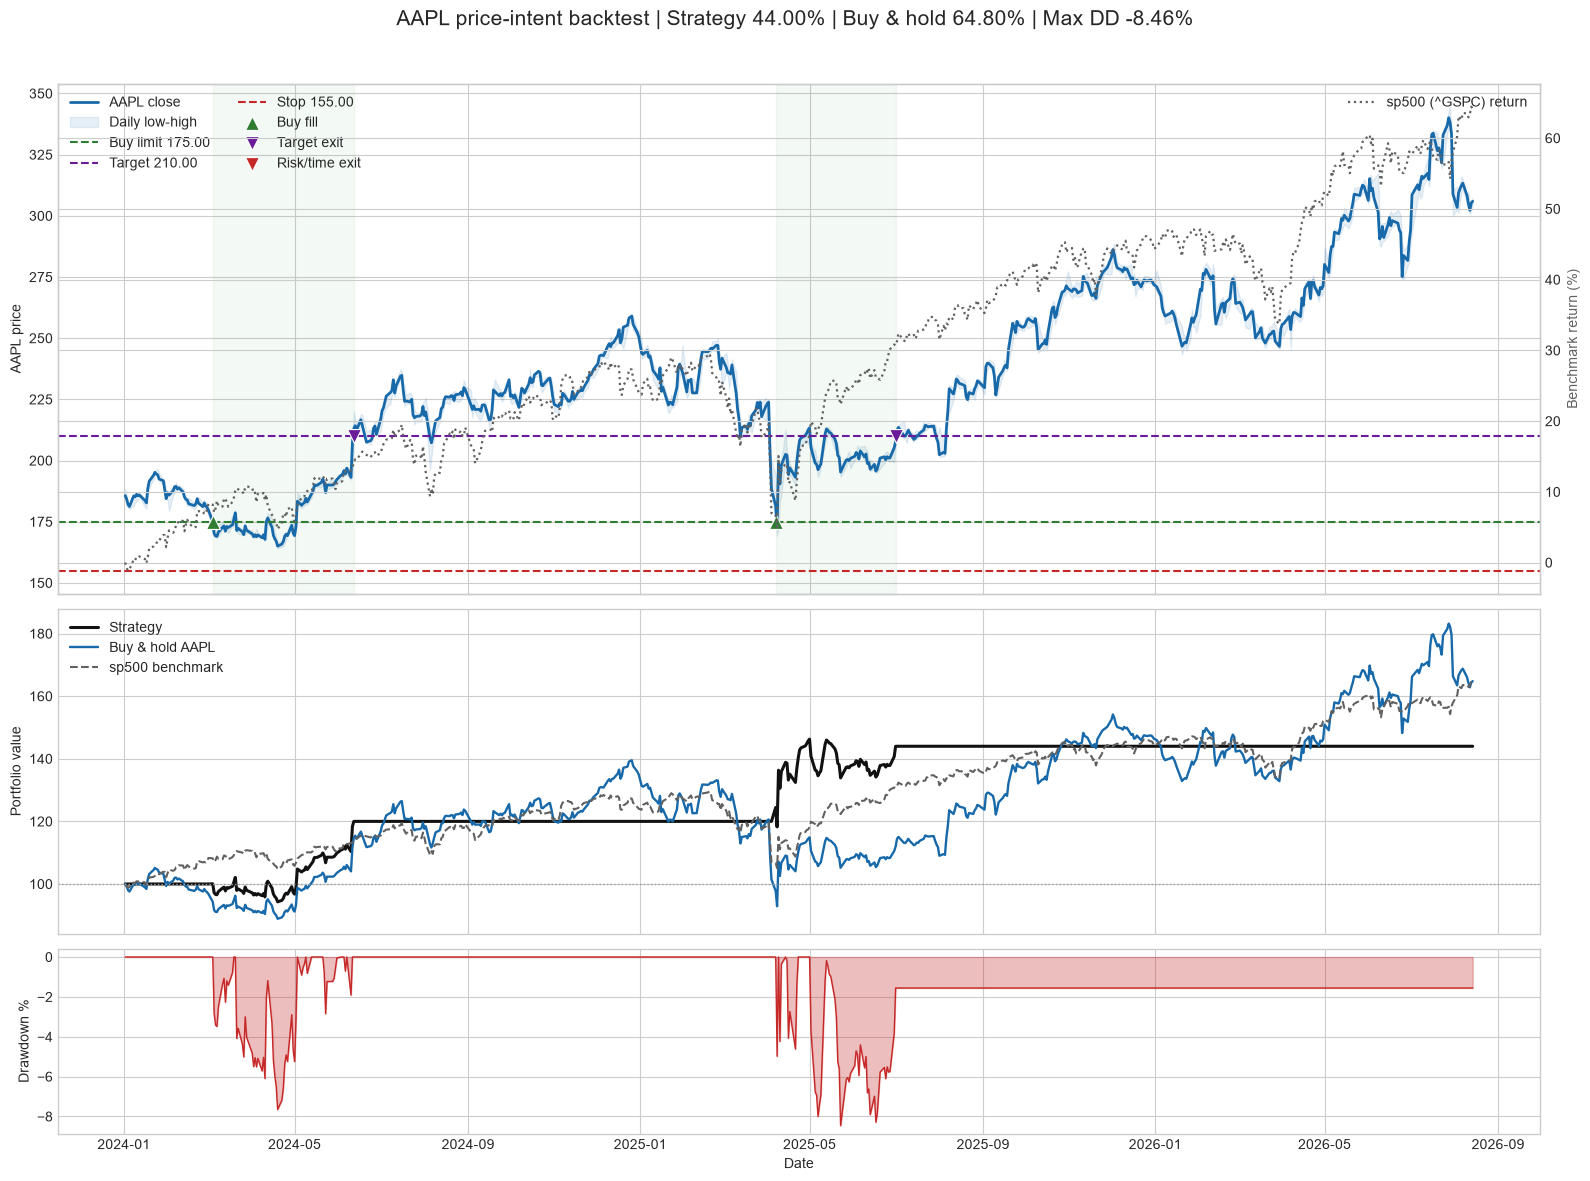

In [6]:
fig, chart_file = plot_backtest_results(
    backtest=backtest,
    benchmark_history=benchmark_history,
    ticker=ticker,
    index_name=index_name,
    benchmark_ticker=benchmark_ticker,
    buy_price=buy_price,
    sell_price=sell_price,
    stop_loss=stop_loss,
    initial_capital=initial_capital,
    chart_output_dir="output" if save_chart else None,
)
if chart_file is not None:
    print(f"Saved chart to {chart_file.resolve()}")

plt.show()

## Interpretation notes

- The blue line in the first panel is the ticker's actual unadjusted daily close over exactly the tested window; the pale band is each day's low-to-high range.
- The strategy uses unadjusted prices because your intended limit, target, and stop are absolute quoted prices. Splits inside the test window can therefore invalidate those fixed levels; use a post-split window or manually adjust the levels.
- Dividends, taxes, borrowing, partial fills, bid/ask spreads beyond configured slippage, and intraday sequencing are not modeled.
- Buy-and-hold and benchmark curves are normalized comparisons. The index check uses today's constituent list and must not be interpreted as proof that the ticker belonged to the index throughout the historical window.
- A daily candle cannot reveal whether its high or low occurred first. Keep `same_day_exit_priority = "stop"` for a conservative assumption, or use intraday data for finer execution modeling.